In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from loaders import *
from reporting import *
from measurements import m_len, m_exl, m_itx
import numpy as np
import sys
import shutil, os

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

In [ ]:
# Set paths
HOME = None # Add path

DATA_HOME = os.path.join(HOME, "rqe_data")
FULL = os.path.join(DATA_HOME, "full")
SAMPLE = os.path.join(DATA_HOME, "sample", "preprocessed")
PRECOMPUTED_METRICS = os.path.join(DATA_HOME, "precomputed_metrics")

ANALYSIS_OUT = os.path.join(HOME, "analysis_out")
if not os.path.exists(ANALYSIS_OUT):
    os.makedirs(ANALYSIS_OUT)

# for consistency in tables / plots
CAMPAIGN_ORDER = ["ICLR-2018", "ICLR-2019", "ICLR-2020", "ICLR-2021", "ICLR-2022", "ICLR-2023", "ICLR-2024", "ICLR-2025", "NeurIPS-2021", "NeurIPS-2022", "NeurIPS-2023", "NeurIPS-2024", "NeurIPS-2025", "ARR-2022", "ARR-2024", "ARR-2025"]

# list all metrics here and give them paper-friendly names
METRICS = ["LEN", "ITX", "REQ", "ACT", "EXL", "GND"]  # order affects tables and plotting, group by criterion
METRICS_LLM = ["ACT", "GND", "ITX"]  # for analysis
METRICS_CHEAP = ["LEN", "EXL", "REQ"]

In [ ]:
# load data
df_full = make_dataframe(FULL)  # only used to report full data counts
df = make_dataframe(SAMPLE)  # by default, everything is about the sample

# keep only accepted and rejected papers
df_full = df_full[df_full["paperDecisionCoarse"].isin(["Accept", "Reject"])]
df = df[df["paperDecisionCoarse"].isin(["Accept", "Reject"])]

# add in-place metrics (takes a sec)
print("Calculating LEN and ITX", file=sys.stderr)
df["LEN"] = df["flattenedReview"].apply(m_len)
df["ITX"] = df.apply(
    lambda row: m_itx(row["seg_summary"], row["seg_strengths"], row["seg_weaknesses_suggestions_questions_comments"]),
    axis=1
)
print("Calculating EXL...", file=sys.stderr)
df["EXL"] = df["flattenedReview"].apply(m_exl)

print("Adding ACT GND REQ...", file=sys.stderr)
# Integrate precomputed measurements
au_lookup = read_au_metrics(os.path.join(PRECOMPUTED_METRICS, "m_act_gnd")) # gnd, act
df = df.merge(au_lookup, on="reviewID", how="left")

req_lookup = read_rq_metric(os.path.join(PRECOMPUTED_METRICS, "m_req")) # req
df = df.merge(req_lookup, on="reviewID", how="left")

for m in METRICS:
    assert m in df.columns, f"Metric {m} not found in dataframe!"

In [5]:
# Review counts in FULL data, by paper decision
# Convention: start with OUT_F = tex export file name, same as \label{} in LaTeX
OUT_F = os.path.join(ANALYSIS_OUT, "review-counts.tex")

review_counts = df_full.groupby(["campaign"])["paperDecisionCoarse"].value_counts().unstack(fill_value=0)
review_counts["Total"] = review_counts.sum(axis=1)
review_counts = review_counts.reindex(CAMPAIGN_ORDER)
review_counts.columns.name = None  # remove var name for table display

tex = review_counts.to_latex(index=True, multirow = True, formatters={"Accept": format_k, "Reject": format_k, "Total": format_k})
with open(OUT_F, "w") as f:
    f.write(tex)

review_counts

,Accept,Reject,Total
campaign,,,
ICLR-2018,1293,1491,2784
ICLR-2019,1528,2804,4332
ICLR-2020,2074,4647,6721
ICLR-2021,3309,6713,10022
ICLR-2022,4217,5985,10202
ICLR-2023,5968,8367,14335
ICLR-2024,8742,13283,22025
ICLR-2025,14940,19938,34878
NeurIPS-2021,10217,519,10736


In [6]:
# Metric ranges based on SAMPLE data
OUT_F = os.path.join(ANALYSIS_OUT, "metric-ranges.tex")

metric_stats_df = df[METRICS].agg(["min", "max", "median", "mean"]).T
tex = metric_stats_df.to_latex(index=True, multirow = True, float_format="%.2f")
with open(OUT_F, "w") as f:
    f.write(tex)
metric_stats_df

,min,max,median,mean
LEN,0.032,28.289,2.494,2.845561
ITX,1.000,99.000,11.000,12.192183
REQ,0.000,72.000,4.000,5.728623
ACT,0.000,5.000,2.500,2.528667
EXL,0.000,103.000,2.000,2.966397
GND,0.000,5.000,3.000,3.079916


In [7]:
# A secondary data frame with outliers removed for plotting
OUTLIER_COLUMNS = ["LEN", "EXL", "ITX", "REQ"]

thresholds = df[OUTLIER_COLUMNS].quantile(0.99)
df_filtered = df[
    (df[OUTLIER_COLUMNS] <= thresholds).all(axis=1)
]
print(len(df_filtered), len(df))

15303 15683


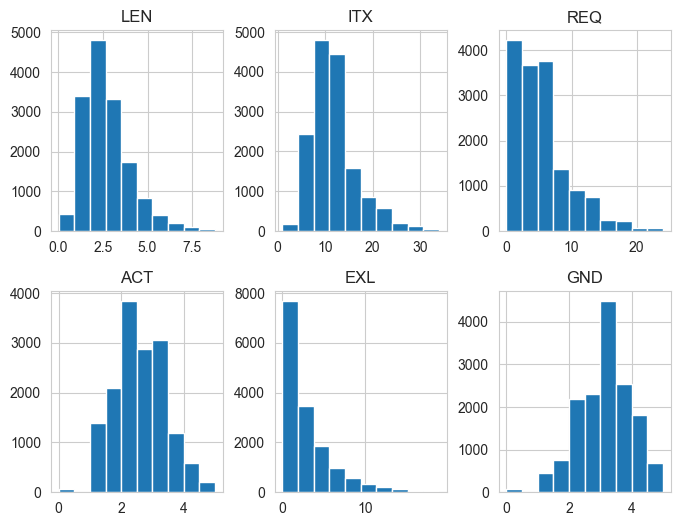

In [25]:
# Metric value distributions.

OUT_F = os.path.join(ANALYSIS_OUT, "metric-distributions.pdf")
# Top 1% removed for better viz (explicitly state in the caption!)
df_filtered[METRICS].hist(layout=(2, 3),
    figsize=(8, 6),
    sharex=False,
    sharey=False)

plt.savefig(OUT_F, format="pdf", bbox_inches="tight",)
plt.show()

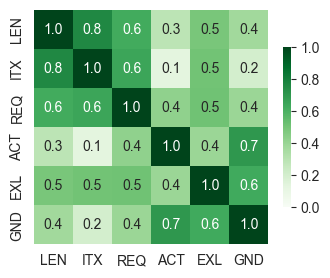

In [41]:
OUT_F = os.path.join(ANALYSIS_OUT, "metric-correlations.pdf")
tmp = df[METRICS]

fig, ax = plt.subplots(figsize=(3.5, 3.5))
sns.heatmap(
    tmp.corr(method="spearman").clip(lower=0), # !!! Currently no negative correlations, but check if metrics are changed
    annot=True,
    fmt=".1f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.5},
    ax=ax
)

plt.tight_layout()
plt.savefig(OUT_F, format="pdf", bbox_inches="tight")
plt.show()
tmp = None  # clear to avoid silly mistakes

In [10]:
# Normalizing the scores to [0;1]
df[METRICS] = (df[METRICS] - df[METRICS].min()) / (df[METRICS].max() - df[METRICS].min())
df["Agg_LLMs"] = df[METRICS_LLM].mean(axis=1)
df["Agg_Cheap"] = df[METRICS_CHEAP].mean(axis=1)
df[["Agg_LLMs", "Agg_Cheap"]].corr(method="spearman")

,Agg_LLMs,Agg_Cheap
Agg_LLMs,1.000000,0.609803
Agg_Cheap,0.609803,1.000000


In [11]:
# Calculating Q
df["Q"] = df[METRICS].mean(axis=1)

In [12]:
df.loc[df["Q"].idxmax()] # our champion

venue                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [13]:
df.loc[df["Q"].idxmin()]

venue                                                                                  ICLR
year                                                                                   2021
campaign                                                                          ICLR-2021
reviewID                                                                        JyDOKd6n_PA
paperID                                                                         CF-ZIuSMXRz
paperTitle                                       Spatio-Temporal Graph Scattering Transform
paperDecision                                                               Accept (Poster)
paperDecisionCoarse                                                                  Accept
flattenedReview                                         Review:\nI will add it tomorrow\n\n
seg_summary                                                                               1
seg_strengths                                                                   

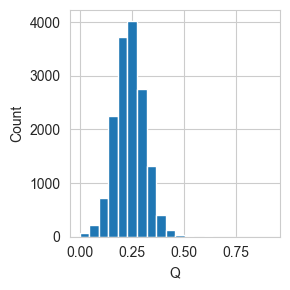

In [47]:
OUT_F = os.path.join(ANALYSIS_OUT, "Q-distribution.pdf")
ax = df["Q"].hist(bins=20, figsize=(3, 3)) # very nice
ax.set_xlabel("Q")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(OUT_F, format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# we will repeat this plot several times, so packing it into a function
def plot_measurement(df, STAT="median", measurement="Q"):
    venues = ["ICLR", "NeurIPS", "ARR"]

    markers = {
        "ICLR": "o",
        "NeurIPS": "s",
        "ARR": "v",
    }

    colors = {
        "ICLR": "tab:blue",
        "NeurIPS": "tab:green",
        "ARR": "tab:orange",
    }

    fig, axes = plt.subplots(
        1, 3,
        figsize=(8, 3),
        sharey=True,
        gridspec_kw={"width_ratios": [2.4, 1.6, 0.8]}
    )

    for ax, venue in zip(axes, venues):
        s = (
            df[df["venue"] == venue]
            .groupby("year")[measurement]
            .agg(STAT)
            .sort_index()
        )

        s.plot(
            ax=ax,
            marker=markers[venue],
            ms=7,
            linewidth=1.5,
            color=colors[venue]
        )

        years = s.index.to_list()
        values = s.values

        ax.set_xticks(years)
        ax.set_xticklabels([f"'{str(y)[-2:]}" for y in years])
        ax.set_xlabel("")
        ax.set_title(venue)
        ax.grid(True, axis="y", alpha=0.3)
        ax.grid(True, axis="x", alpha=0.6)

        # add values to points
        for x, y in zip(years, values):
            ax.annotate(
                f"{y:.3f}",
                (x, y),
                xytext=(0, 5), # put above point
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8
            )

    # shared y-axis
    axes[0].set_ylabel(f"{measurement} ({STAT})")
    axes[0].set_yticks(np.arange(0, 0, 0.1))

    return fig

# Make a function to plot accept vs reject in one plot for a given measurement, e.g. Q
def plot_iclr_measurement(df, STAT="median", measurement="Q"):
    # Filter for ICLR once to simplify downstream logic
    df_iclr = df[df["venue"] == "ICLR"]
    
    decisions = ["Accept", "Reject"]
    
    # Dictionaries to style the two distinct lines
    markers = {
        "Accept": "o",
        "Reject": "d",
    }
    
    colors = {
        "Accept": "tab:red",
        "Reject": "tab:green",
    }

    # Create a single plot figure
    fig, ax = plt.subplots(figsize=(6, 4))

    # We collect all years plotted to ensure our x-ticks are comprehensive
    all_plotted_years = set()

    for decision in decisions:
        # Filter by the specific decision status
        s = (
            df_iclr[df_iclr["paperDecisionCoarse"] == decision]
            .groupby("year")[measurement]
            .agg(STAT)
            .sort_index()
        )
        
        # Skip plotting if there is no data for a decision
        if s.empty:
            print("Weird")
            continue

        s.plot(
            ax=ax,
            marker=markers[decision],
            ms=7,
            linewidth=1.5,
            color=colors[decision],
            label=decision # Add label for the legend
        )

        years = s.index.to_list()
        values = s.values
        all_plotted_years.update(years)

        # Add values to points
        for x, y in zip(years, values):
            # To prevent overlapping text, we put 'Accept' values above the point 
            # and 'Reject' values below the point.
            if decision == "Accept":
                xytext = (0, 5)
                va = "bottom"
            else:
                xytext = (0, -5)
                va = "top"
                
            ax.annotate(
                f"{y:.3f}",
                (x, y),
                xytext=xytext,
                textcoords="offset points",
                ha="center",
                va=va,
                fontsize=8,
                color=colors[decision] # Matches text color to the line color
            )

    # Formatting the axes and title
    if all_plotted_years:
        sorted_years = sorted(list(all_plotted_years))
        ax.set_xticks(sorted_years)
        ax.set_xticklabels([f"'{str(y)[-2:]}" for y in sorted_years])
        
    ax.set_xlabel("")
    ax.set_ylabel(f"{measurement} ({STAT})")
    ax.set_yticks(np.arange(0.0, 0.51, 0.1))
    ax.set_title("ICLR")
    ax.grid(True, axis="y", alpha=0.3)
    ax.grid(True, axis="x", alpha=0.6)
    
    # Add a legend so we know which line is which
    ax.legend(title="Decision", loc="best")

    return fig

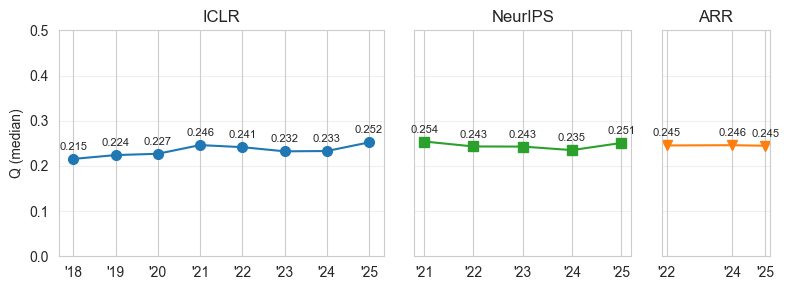

In [ ]:
measurement = "Q"
OUT_F = os.path.join(ANALYSIS_OUT, "Q-venues-time-wide.pdf")
STAT = "median"  # consistency with top/bottom 1% plot later

fig = plot_measurement(df, STAT, measurement=measurement)
fig.tight_layout()
fig.savefig(OUT_F, format="pdf", bbox_inches="tight")
plt.show()

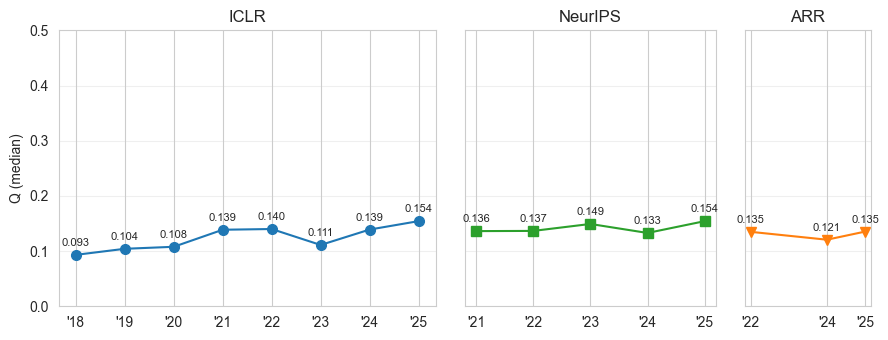

In [ ]:
measurement = "Q"
OUT_F = os.path.join(ANALYSIS_OUT, "Q-bottom.pdf")
lowest = df[df["Q"] <= df.groupby("campaign")["Q"].transform(lambda s: s.quantile(0.1))]
fig = plot_measurement(lowest, STAT, measurement=measurement)
fig.tight_layout()
fig.savefig(OUT_F, format="pdf", bbox_inches="tight")
plt.show()

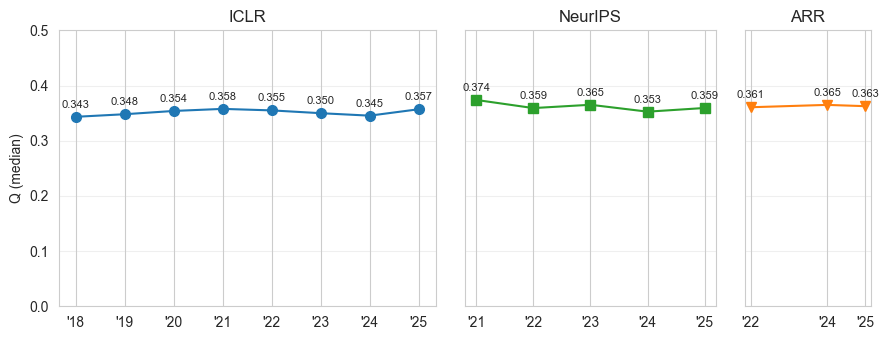

In [ ]:
measurement = "Q"
OUT_F = os.path.join(ANALYSIS_OUT, "Q-top.pdf")
highest = df[df["Q"] >= df.groupby("campaign")["Q"].transform(lambda s: s.quantile(0.9))]
fig = plot_measurement(lowest, STAT, measurement=measurement)
fig.tight_layout()
fig.savefig(OUT_F, format="pdf", bbox_inches="tight")
plt.show()

In [20]:
# Accept vs reject simple stats
df[df["venue"]=="ICLR"].groupby("paperDecisionCoarse")["Q"].agg(["mean", "median"])

,mean,median
paperDecisionCoarse,,
Accept,0.240305,0.240386
Reject,0.231783,0.230363


In [ ]:
# Printing out top and bottom 1% reviews for inspection

output_dir = os.path.join(ANALYSIS_OUT, "outlier_reviews")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

q_low = df["Q"].quantile(0.01)
q_high = df["Q"].quantile(0.99)
bottom = df[df["Q"] <= q_low]
top = df[df["Q"] >= q_high]

b1out = os.path.join(output_dir, "bottom_1_percent")
shutil.rmtree(b1out)
os.mkdir(b1out)

t1out = os.path.join(output_dir, "top_1_percent")
shutil.rmtree(t1out)
os.mkdir(t1out)

write_reviews(bottom, b1out, ascending=True)
write_reviews(top, t1out, ascending=False)
print("Outlier reviews printed to", output_dir, file=sys.stderr)

### Bootstrap test

In [ ]:
import scipy.stats as stats
import numpy as np

def diff_means(a, b):
    return np.mean(b) - np.mean(a)

def diff_median(a, b):
    return np.median(b) - np.median(a)

campaignsICLR = ["ICLR-2018", "ICLR-2019", "ICLR-2020", "ICLR-2021", "ICLR-2022", "ICLR-2023", "ICLR-2024", "ICLR-2025"]
campaignsNeurIPS = ["NeurIPS-2021", "NeurIPS-2022", "NeurIPS-2023", "NeurIPS-2024", "NeurIPS-2025"]
campaignsARR = ["ARR-2022", "ARR-2024", "ARR-2025"]

def bootstrap_test(campaigns, df, measurement="Q"):
    campaign_type = campaigns[0].split("-")[0]

    correction_factor = len(campaigns) * (len(campaigns) - 1) // 2
    correctedAlpha = 0.01/correction_factor

    # Make a table of all pairwise comparisons
    matrix = pd.DataFrame(index=campaigns, columns=campaigns)
    for i in range(len(campaigns)):
        for j in range(len(campaigns)):
            campaign1 = campaigns[i]
            campaign2 = campaigns[j]
            if i >= j:
                matrix.iloc[i, j] = "-"
                continue

            x = df.loc[df["campaign"] == campaign1, measurement].dropna().to_numpy()
            y = df.loc[df["campaign"] == campaign2, measurement].dropna().to_numpy()

            results = stats.bootstrap(
                (x, y),
                statistic=diff_median,
                n_resamples=10000,
                confidence_level=1 - correctedAlpha,
                random_state=123,
                method="percentile"
            )
            
            significant = results.confidence_interval.low * results.confidence_interval.high > 0
            cistr = f"[{round(results.confidence_interval.low, 3)}, {round(results.confidence_interval.high, 3)}]" + (" *" if significant else "")
            matrix.iloc[i, j] = cistr

    OUTPUT_PATH = os.path.join(ANALYSIS_OUT, "statistical-significance", f"pairwise_bootstrap_CI_Q_scipy_{campaign_type}.tex")
    matrix.columns.name = None  # remove var name for table display
    tex = matrix.to_latex(index=True, multirow = True)
    with open(OUTPUT_PATH, "w") as f:
        f.write(tex)
    # matrix.to_csv(os.path.join(ANALYSIS_OUT, "statistical-significance", f"pairwise_bootstrap_CI_Q_scipy_{campaign_type}.csv"), index=True)

measurement = "GND"
bootstrap_test(campaignsICLR, df, measurement=measurement)
bootstrap_test(campaignsNeurIPS, df, measurement=measurement)
bootstrap_test(campaignsARR, df, measurement=measurement)

# Scraps (Tidy before publication)

In [ ]:
# Mean / median quality by year and venue
OUT_F = os.path.join(ANALYSIS_OUT, "Q-venues-time.pdf")
STAT = "median"  # consistency with top/bottom 1% plot later

plt.figure(figsize=(4, 4))

ax = df[df["venue"] == "ICLR"].groupby("year")["Q"].agg(STAT).plot(label="ICLR", marker="o", ms=4)
df[df["venue"] == "ARR"].groupby("year")["Q"].agg(STAT).plot(ax=ax, label="ARR", marker="v", ms=4)
df[df["venue"] == "NeurIPS"].groupby("year")["Q"].agg(STAT).plot(ax=ax, label="NeurIPS", marker="s", ms=4)


ax.set_yticks(np.arange(0, 0.51, 0.1))  # Note:  plot full range for context, metric inflated by outliers
ax.legend()
ax.set_ylabel(f"Q ({STAT}) by venue and year")
plt.tight_layout()
plt.savefig(OUT_F, format="pdf", bbox_inches="tight")
plt.show()

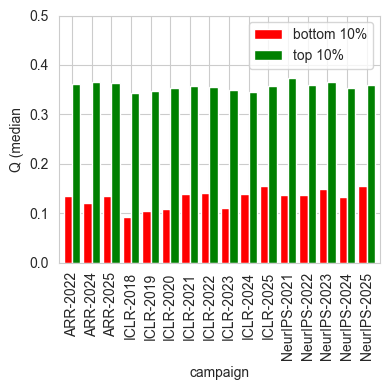

In [22]:
# Compare lowest 10% and highest 10% per campaign
OUT_F = os.path.join(ANALYSIS_OUT, "Q-top-bottom-10percent.pdf")

lowest = (df.groupby("campaign")["Q"] # bottom 10% per campaign
          .apply(lambda s: s[s <= s.quantile(0.1)])
          .groupby("campaign").agg(STAT)
          .rename("bottom 10%"))

highest = (df.groupby("campaign")["Q"] # top 10% per campaign
          .apply(lambda s: s[s >= s.quantile(0.9)])
          .groupby("campaign").agg(STAT)
          .rename("top 10%"))

tmp = pd.concat([lowest, highest], axis=1).sort_index()

ax = tmp.plot(kind="bar", color=["red", "green"], width=0.85, figsize=(4, 4),)
ax.set_ylabel(f"Q ({STAT}")
ax.set_yticks(np.arange(0, 0.51, 0.1))
ax.legend()
plt.tight_layout()

plt.savefig(OUT_F, format="pdf", bbox_inches="tight")
plt.show()
tmp = None

In [ ]:
# Here is our champion of m_len
df.loc[df["m_len"].idxmax()]
# ICLR-2019, https://openreview.net/forum?id=B1g30j0qF7¬eId=SkgZdQ0t37.

In [ ]:
# Outlier removal

TO_FILTER = ["m_len", "m_exl", "m_itx", "m_req"]

#thresholds = df_sample[TO_FILTER].quantile(0.99)
#df_filtered = df_sample[
#    (df_sample[TO_FILTER] <= thresholds).all(axis=1)
#]

mask_outlier = False
for col in TO_FILTER:
    s = df[col]
    #lower, upper = s.quantile([0.01, 0.99])  # 1% tails left and right
    upper = s.quantile(0.99)  # only remove top 1%
    mask_outlier |= (s > upper)  # add everything that does NOT fit into the range to the mask ((s < lower) |

df_outliers = df[mask_outlier]
df_outliers[["reviewID", "campaign", "flattenedReview"]].to_json(
    "filtered_out_rows.json",
    orient="records",
    lines=True,
    indent=2
)

df_filtered = df[~mask_outlier]  # invert the mask


print(f"Removed {len(df) - len(df_filtered)} outliers, was {len(df)}, now {len(df_filtered)} reviews.")

# No outliner detection - top and legitimate reviews, bottom are genuine bad cases (mostly)